In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score, mean_squared_error
import joblib

In [2]:
from google.colab import files
uploading = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic.csv


In [4]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.00,yes,no,2.0,3.0,Sometimes,no,2.00,no,0.00,1.000,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.00,yes,no,3.0,3.0,Sometimes,yes,3.00,yes,3.00,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.00,yes,no,2.0,3.0,Sometimes,no,2.00,no,2.00,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.00,no,no,3.0,3.0,Sometimes,no,2.00,no,2.00,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.80,no,no,2.0,1.0,Sometimes,no,2.00,no,0.00,0.000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.41,yes,yes,3.0,3.0,Sometimes,no,1.73,no,1.68,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,22,1.75,133.74,yes,yes,3.0,3.0,Sometimes,no,2.01,no,1.34,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,23,1.75,133.69,yes,yes,3.0,3.0,Sometimes,no,2.05,no,1.41,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24,1.74,133.35,yes,yes,3.0,3.0,Sometimes,no,2.85,no,1.14,0.586,Sometimes,Public_Transportation,Obesity_Type_III


In [5]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.418986,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.533996,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.390000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())
data_cleaned = df.drop_duplicates()

Number of duplicate rows: 24


In [8]:
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [9]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


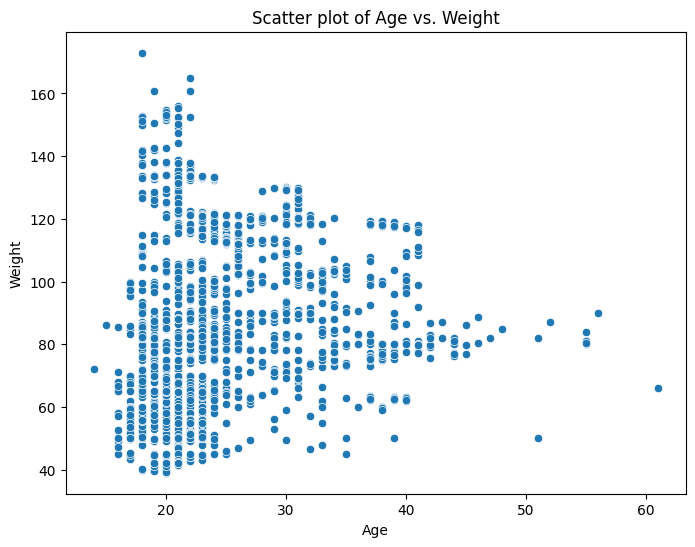

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Weight')
plt.title('Scatter plot of Age vs. Weight')
plt.xlabel('Age')
plt.ylabel('Weight')
plt.show()

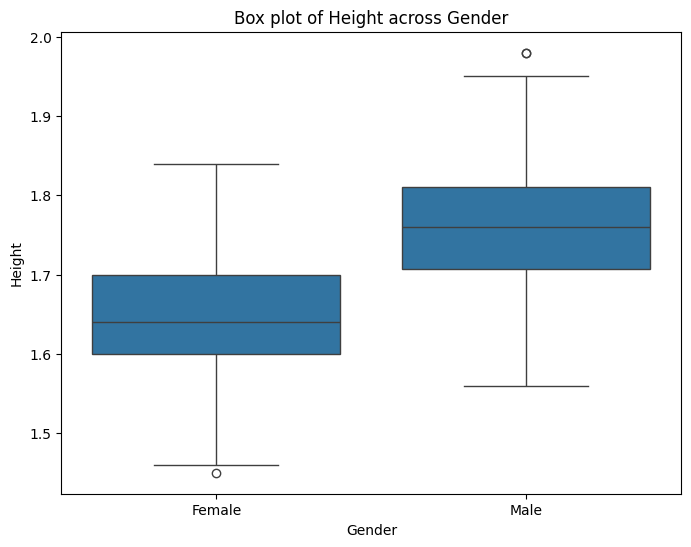

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Height')
plt.title('Box plot of Height across Gender')
plt.xlabel('Gender')
plt.ylabel('Height')
plt.show()

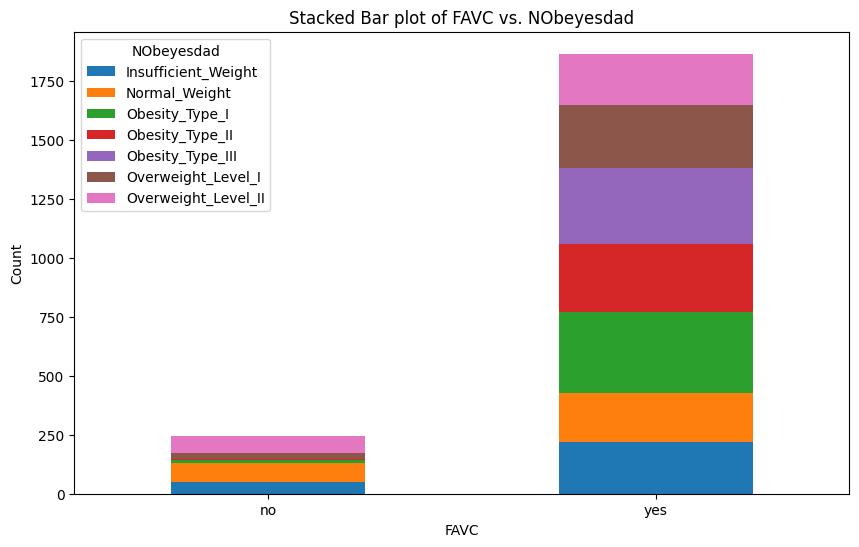

In [12]:
cross_tab = pd.crosstab(df['FAVC'], df['NObeyesdad'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Stacked Bar plot of FAVC vs. NObeyesdad')
plt.xlabel('FAVC')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='NObeyesdad')
plt.show()

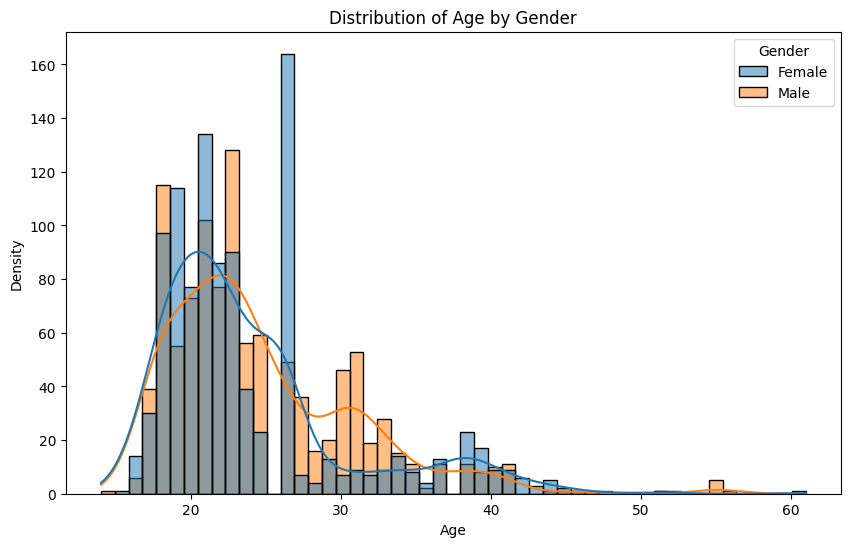

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Gender', kde=True)
plt.title('Distribution of Age by Gender')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

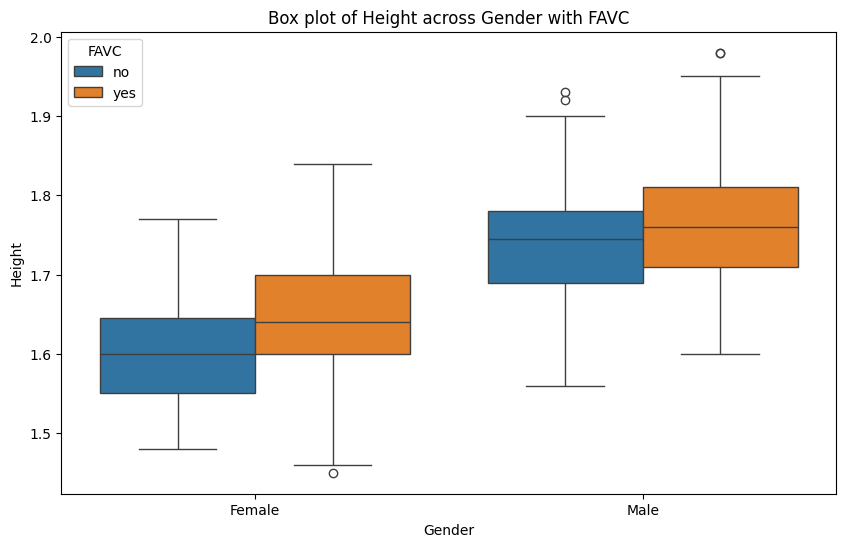

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Height', hue='FAVC')
plt.title('Box plot of Height across Gender with FAVC')
plt.xlabel('Gender')
plt.ylabel('Height')
plt.legend(title='FAVC')
plt.show()

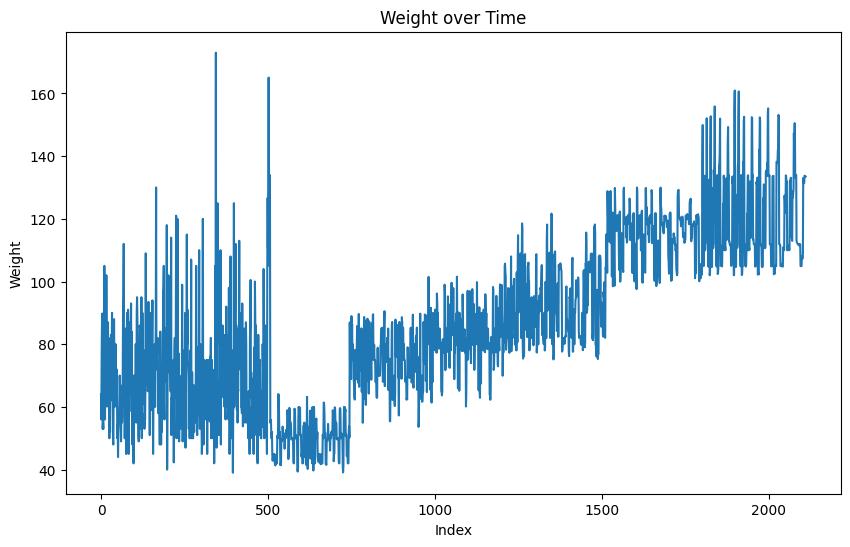

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x=df.index, y='Weight')
plt.title('Weight over Time')
plt.xlabel('Index')
plt.ylabel('Weight')
plt.show()

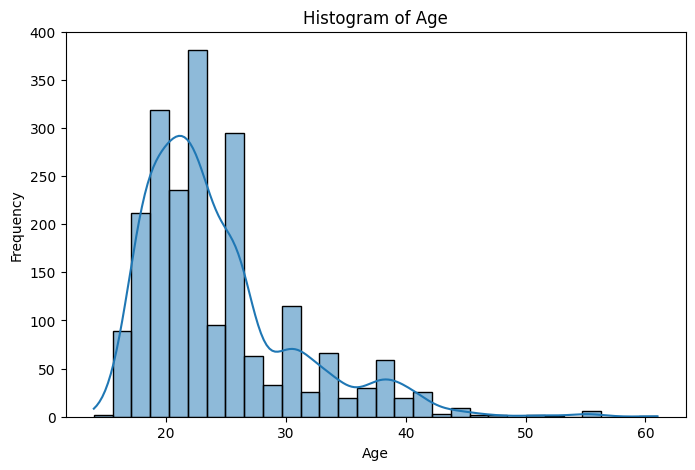

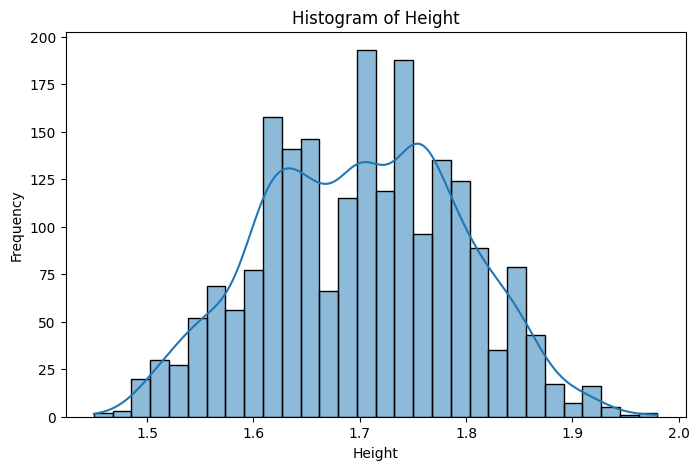

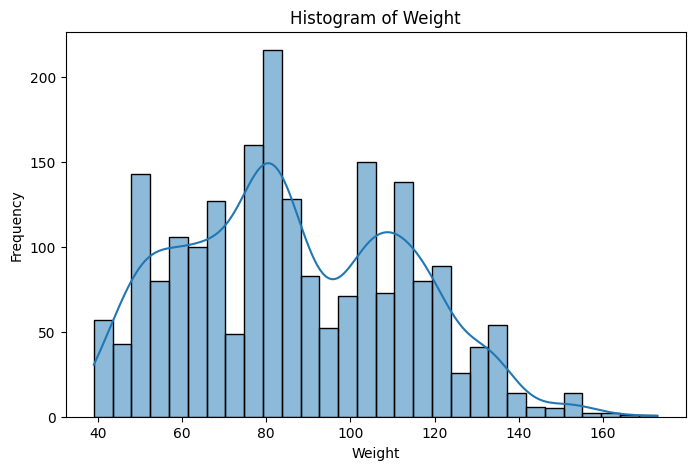

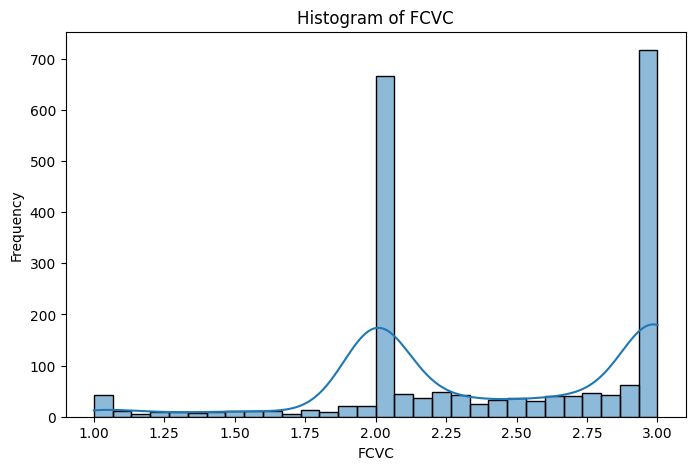

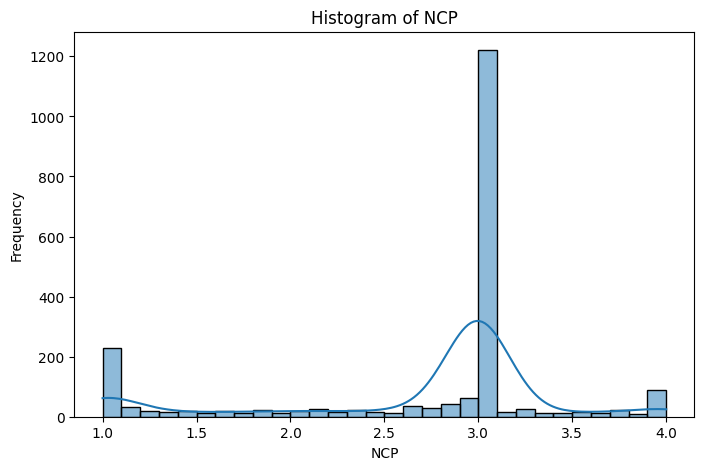

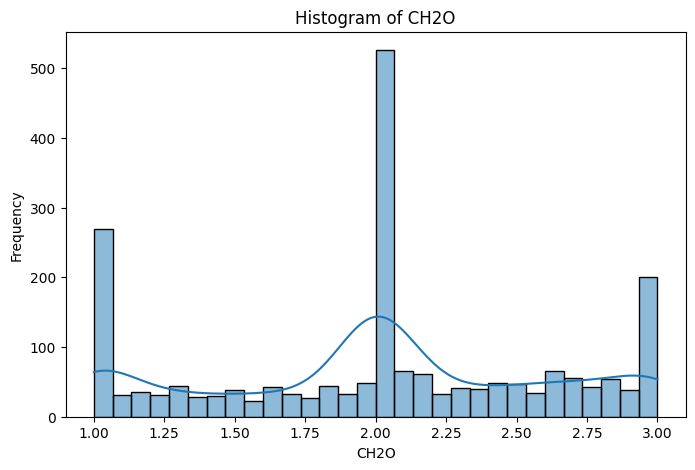

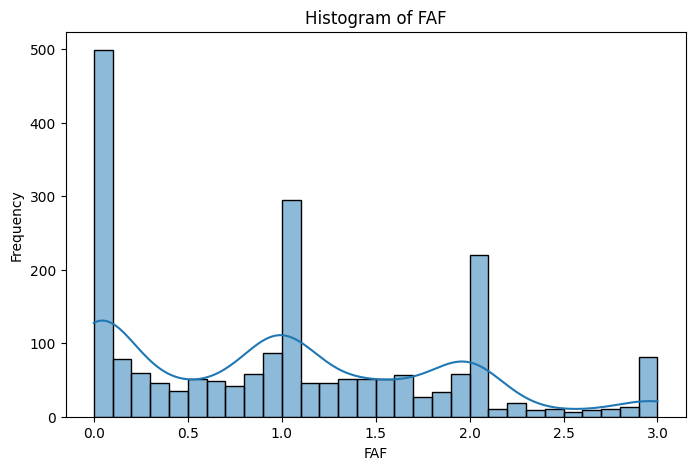

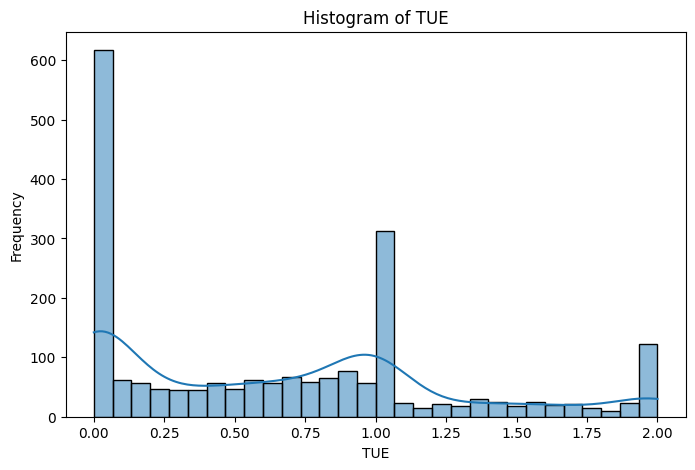

In [16]:
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, bins=30, kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

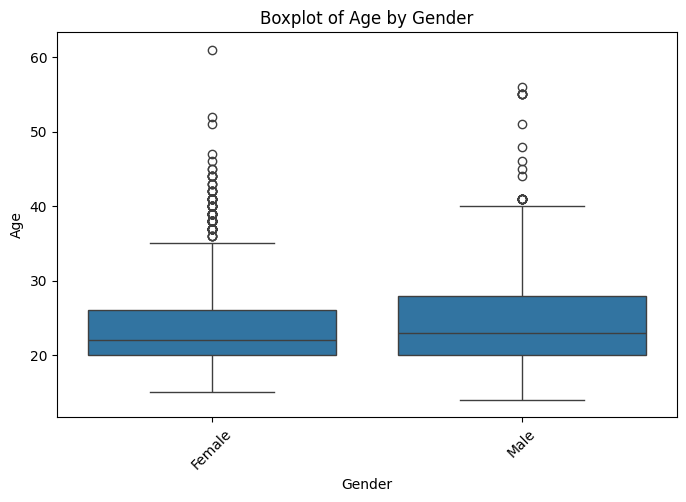

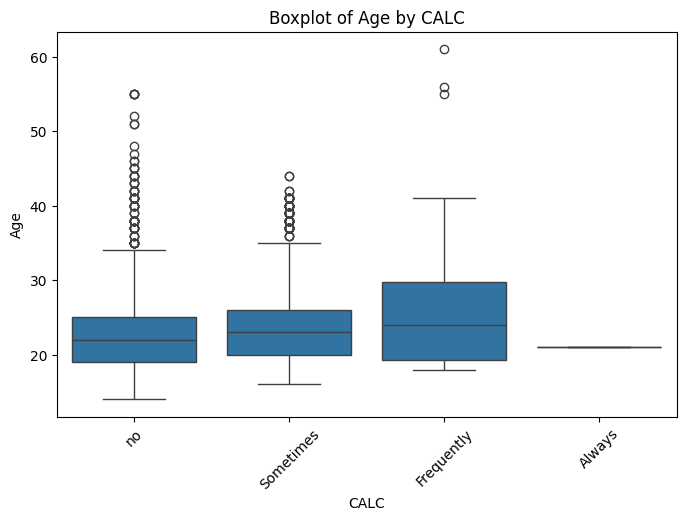

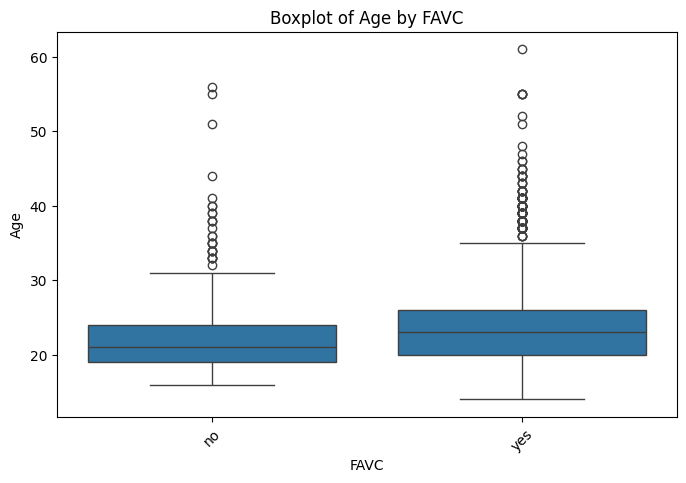

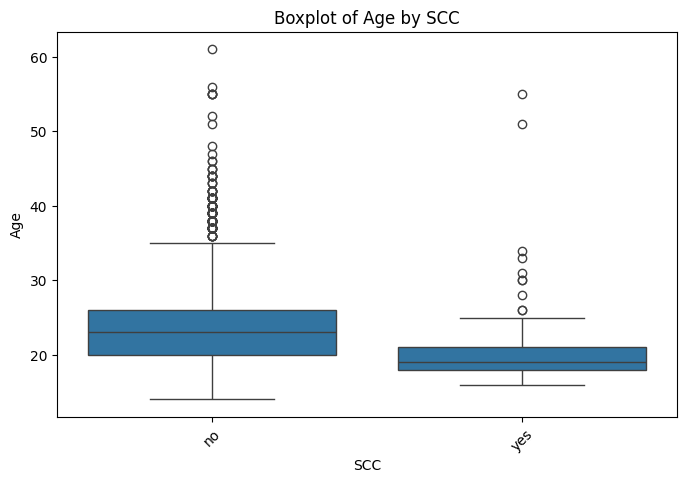

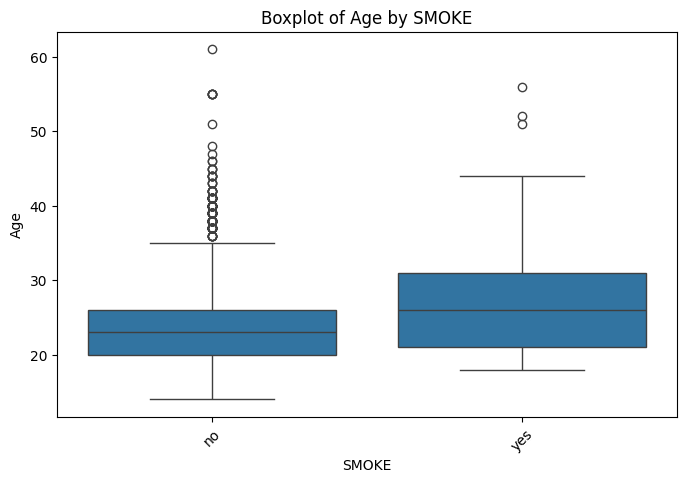

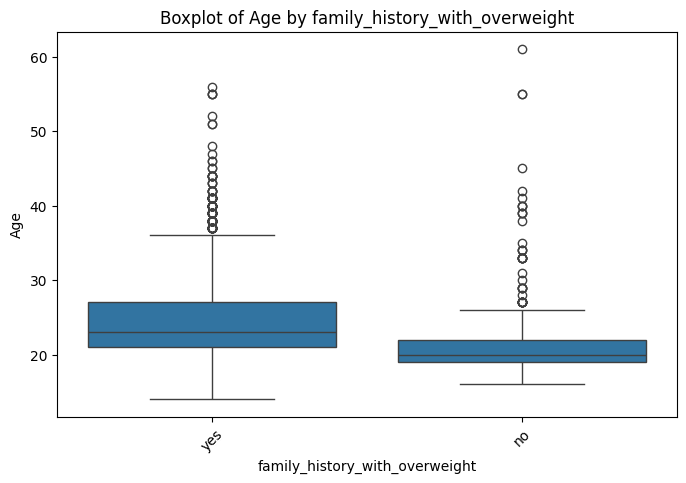

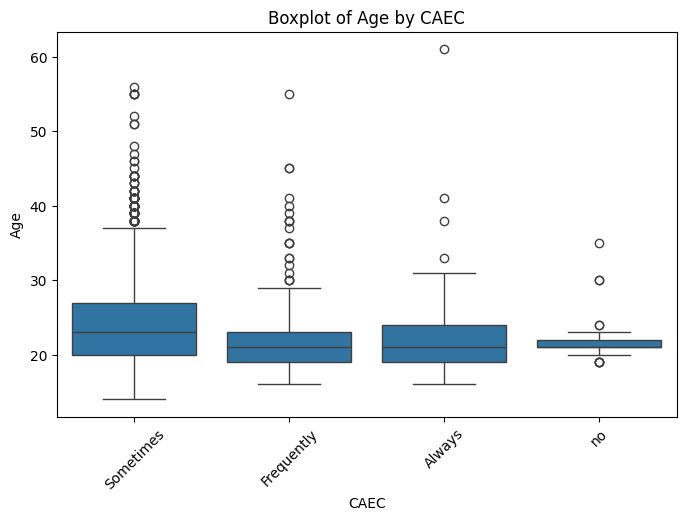

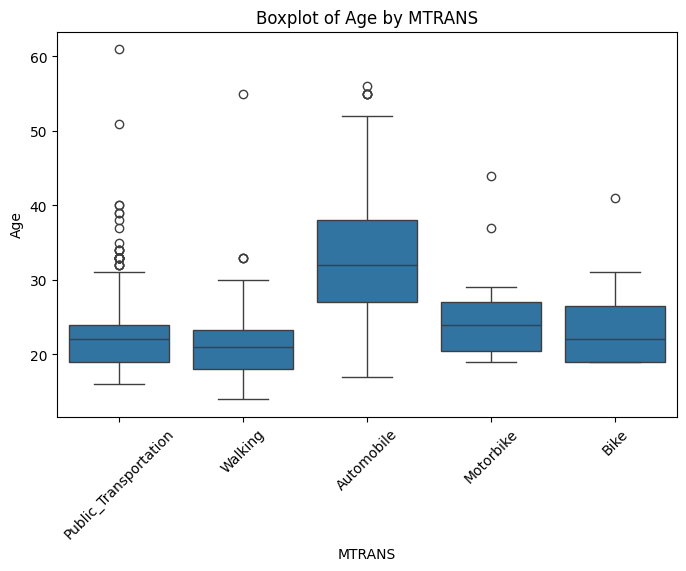

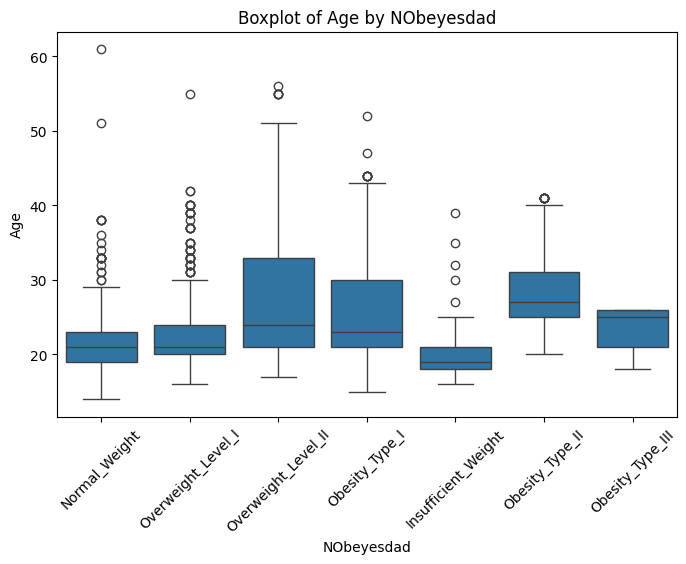

In [17]:
categorical_features = ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS', 'NObeyesdad']
for cat_feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=cat_feature, y='Age')
    plt.title(f'Boxplot of Age by {cat_feature}')
    plt.xlabel(cat_feature)
    plt.ylabel('Age')
    plt.xticks(rotation=45)
    plt.show()

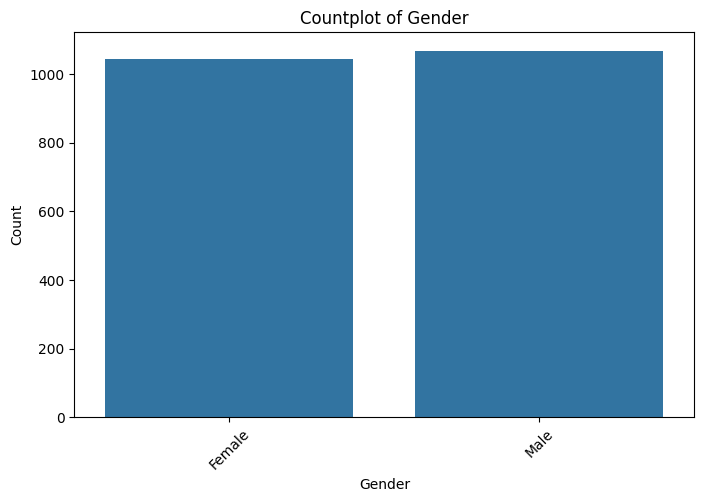

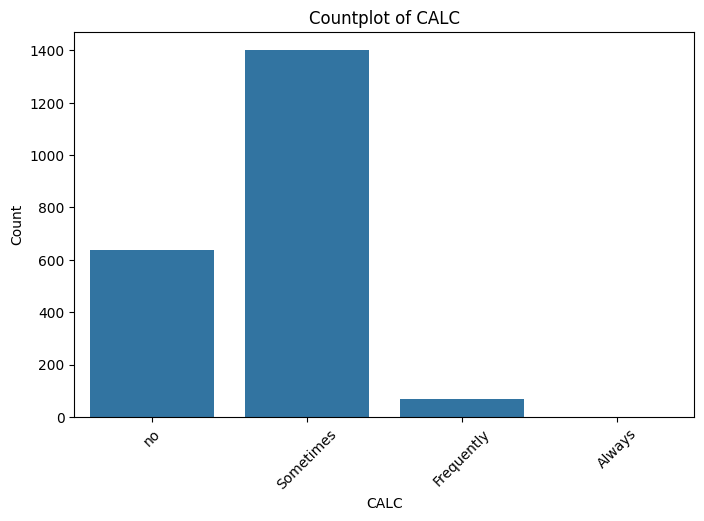

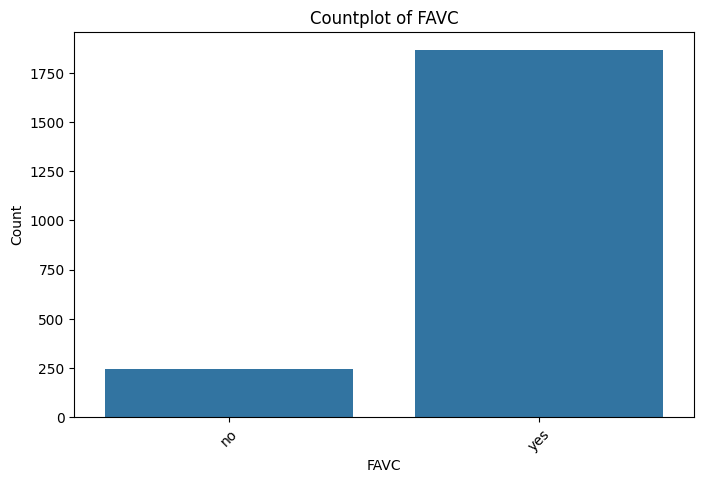

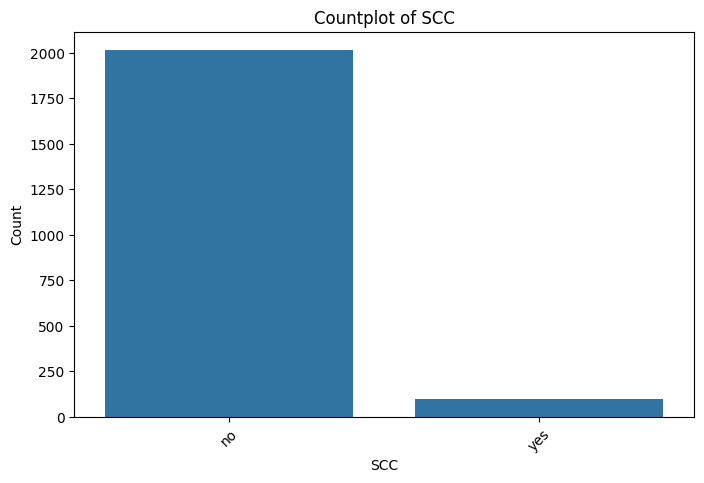

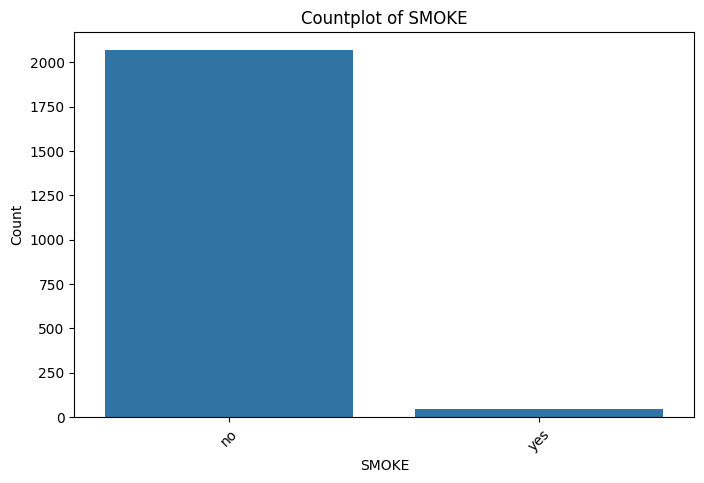

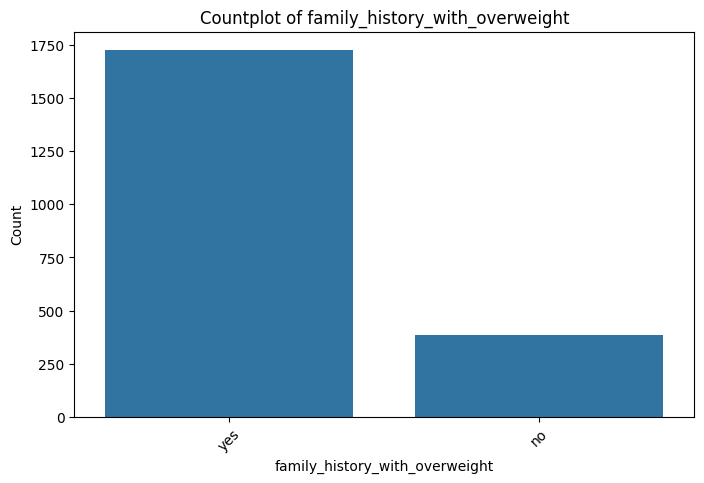

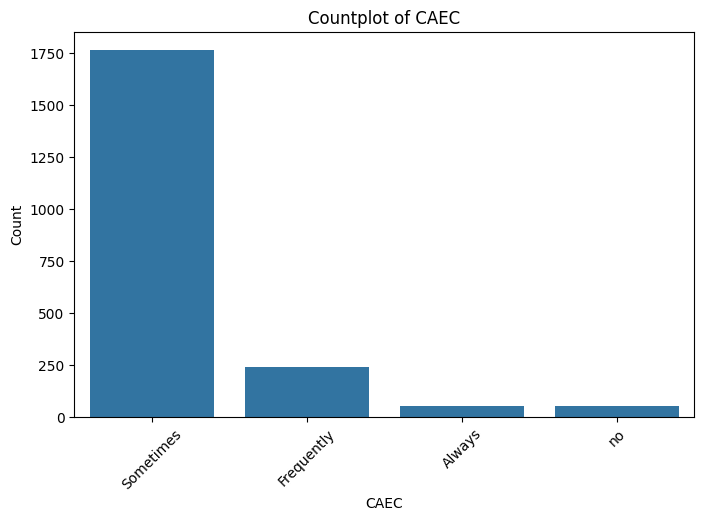

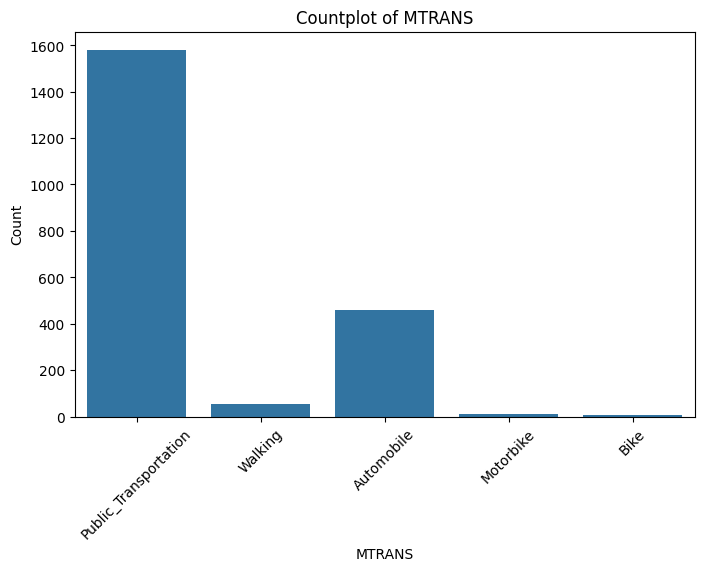

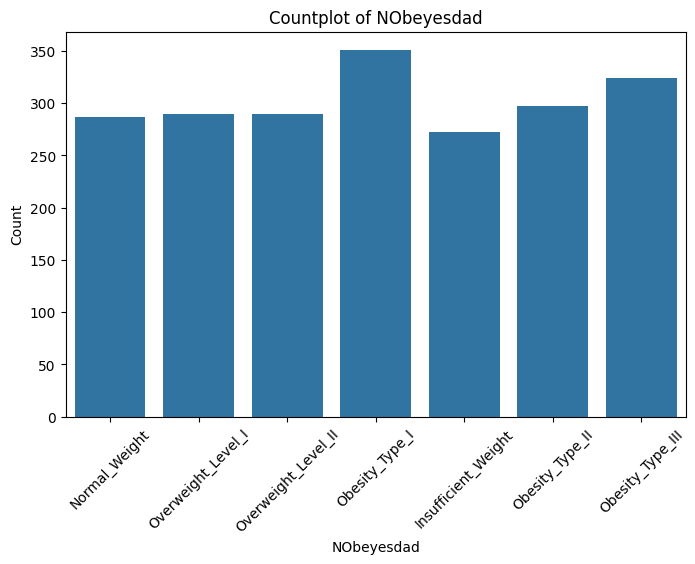

In [18]:
for cat_feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=cat_feature)
    plt.title(f'Countplot of {cat_feature}')
    plt.xlabel(cat_feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

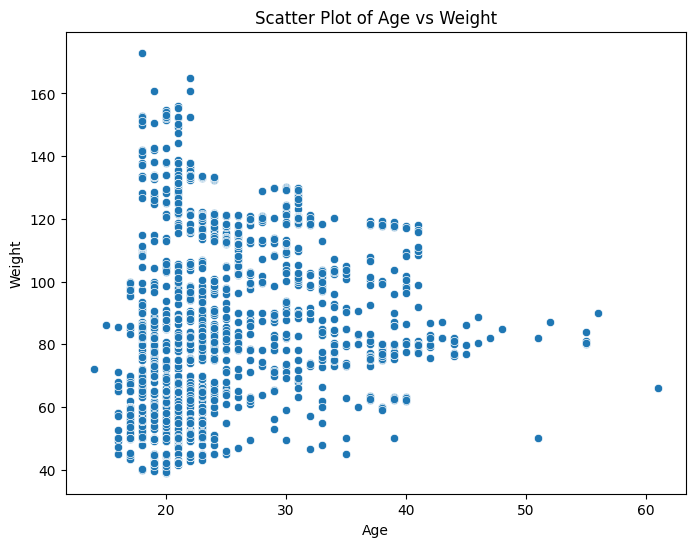

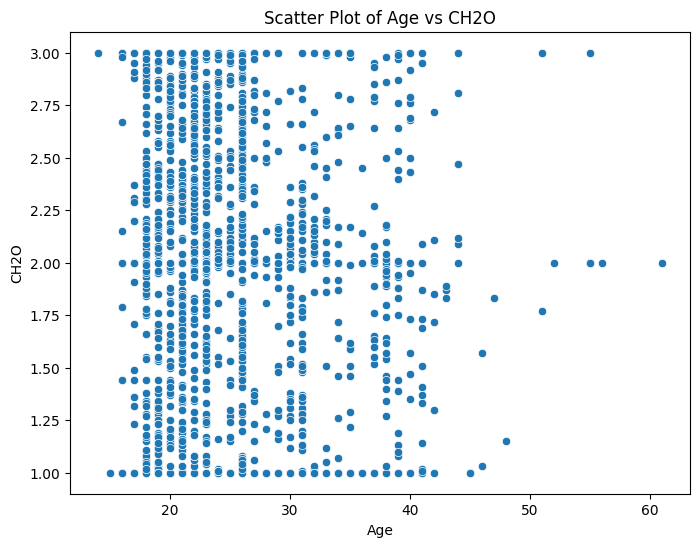

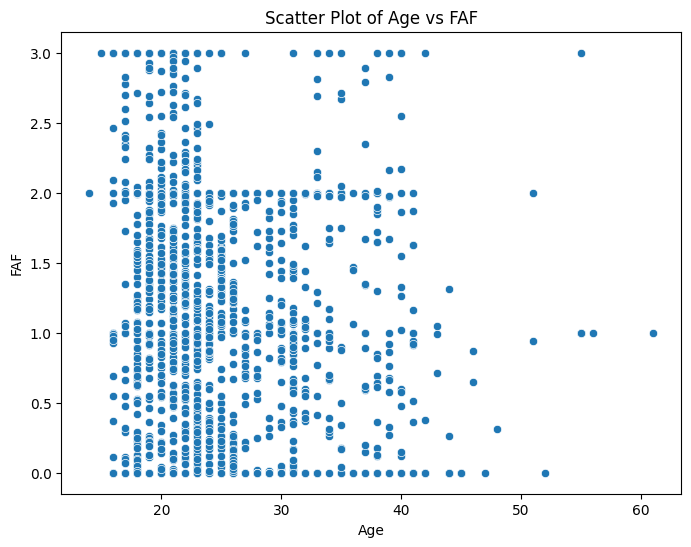

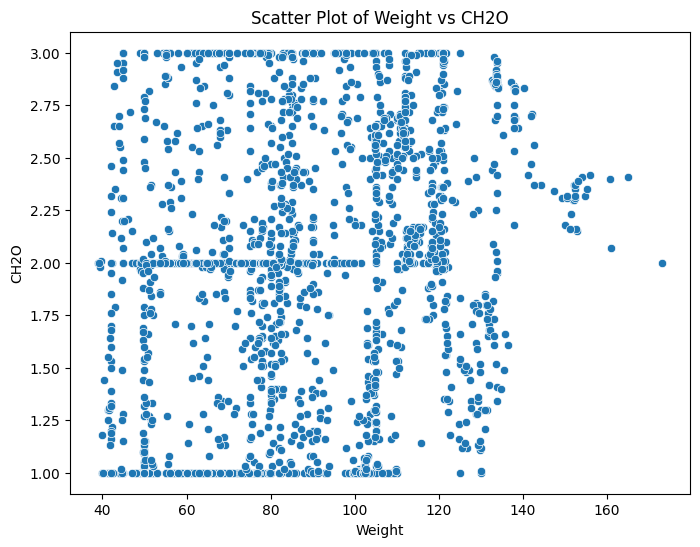

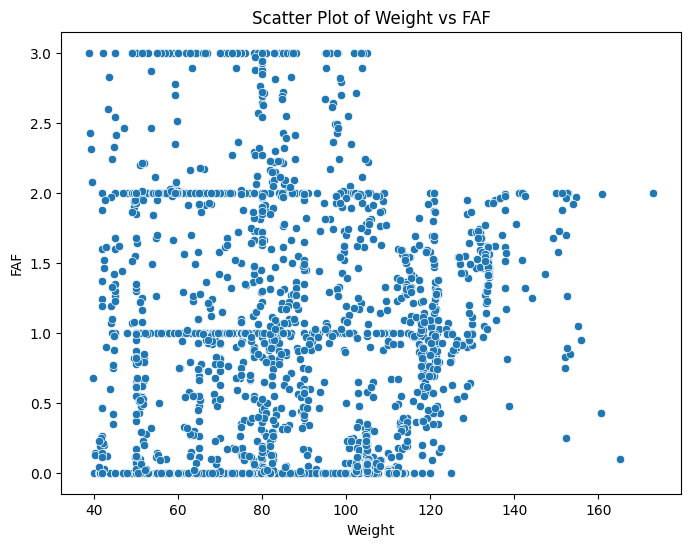

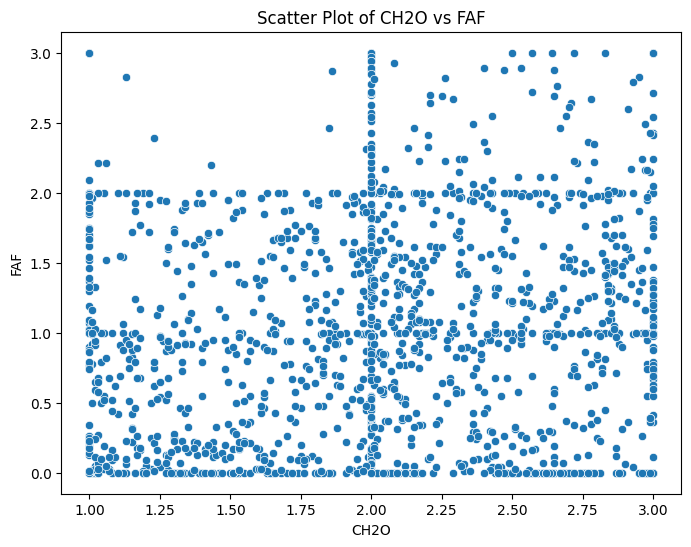

In [19]:
selected_numerical_features = ['Age', 'Weight', 'CH2O', 'FAF']

for i in range(len(selected_numerical_features)):
    for j in range(i + 1, len(selected_numerical_features)):
        feature1 = selected_numerical_features[i]
        feature2 = selected_numerical_features[j]
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=df, x=feature1, y=feature2)
        plt.title(f'Scatter Plot of {feature1} vs {feature2}')
        plt.xlabel(feature1)
        plt.ylabel(feature2)
        plt.show()

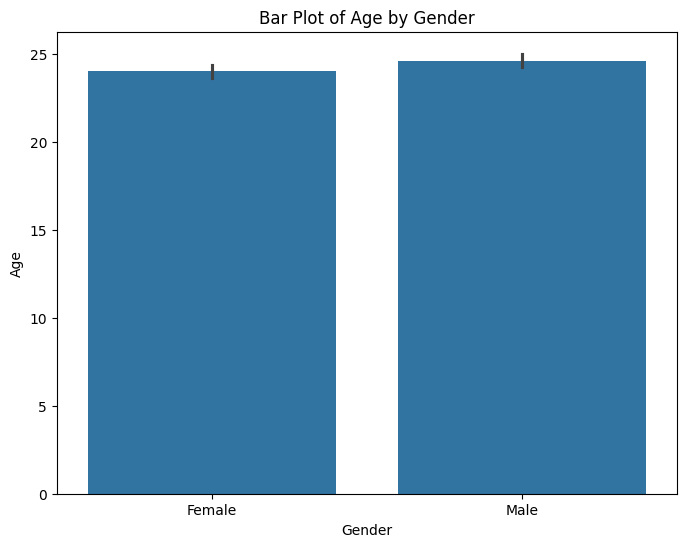

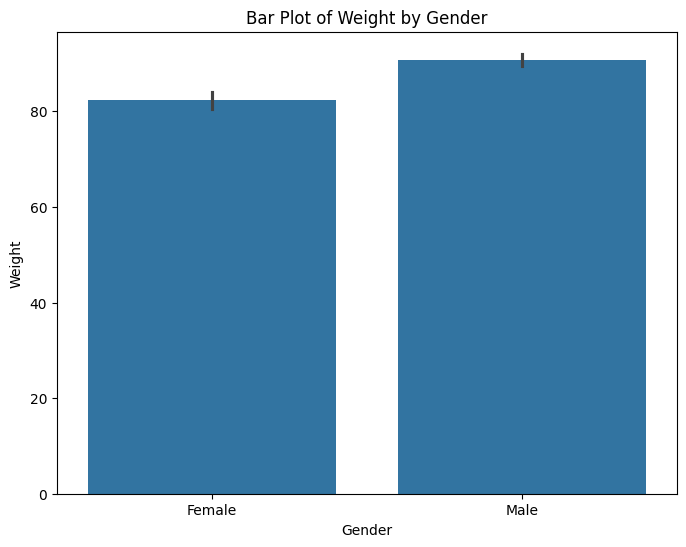

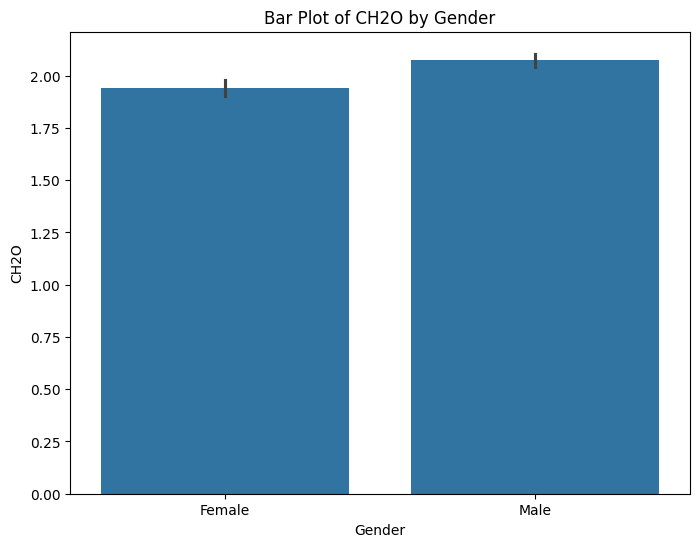

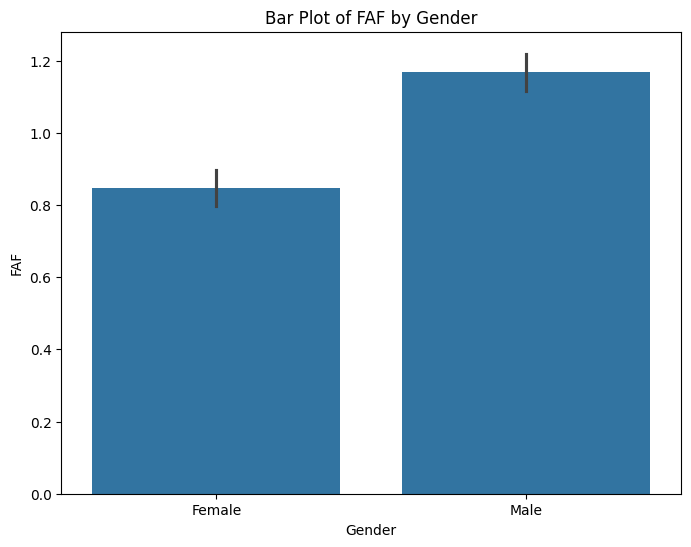

In [20]:
selected_numerical_features = ['Age', 'Weight', 'CH2O', 'FAF']
categorical_feature = 'Gender'
for feature in selected_numerical_features:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df, x=categorical_feature, y=feature)
    plt.title(f'Bar Plot of {feature} by {categorical_feature}')
    plt.xlabel(categorical_feature)
    plt.ylabel(feature)
    plt.show()

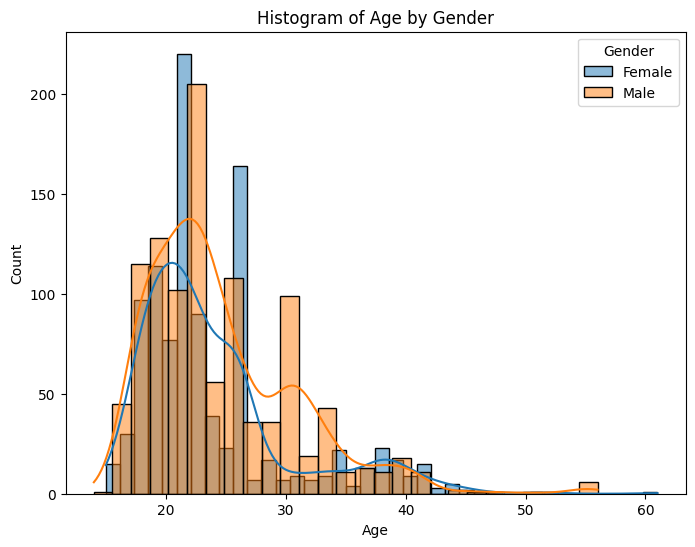

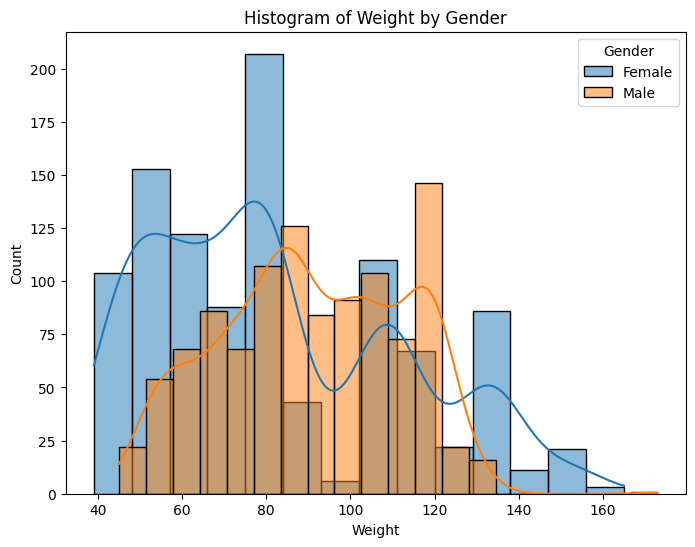

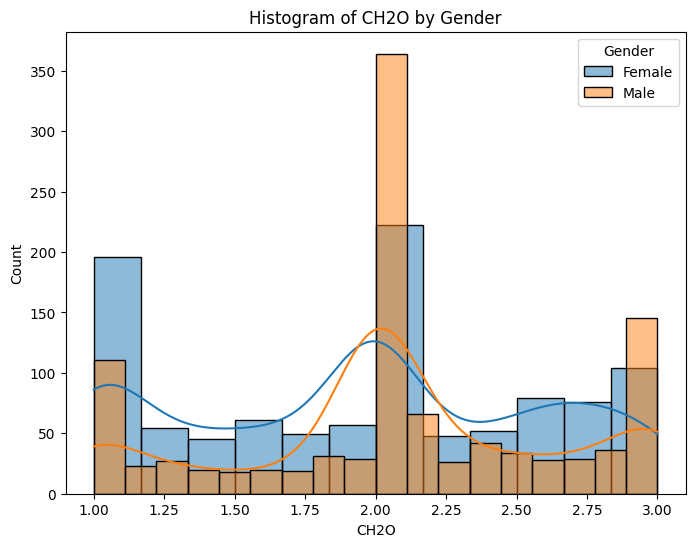

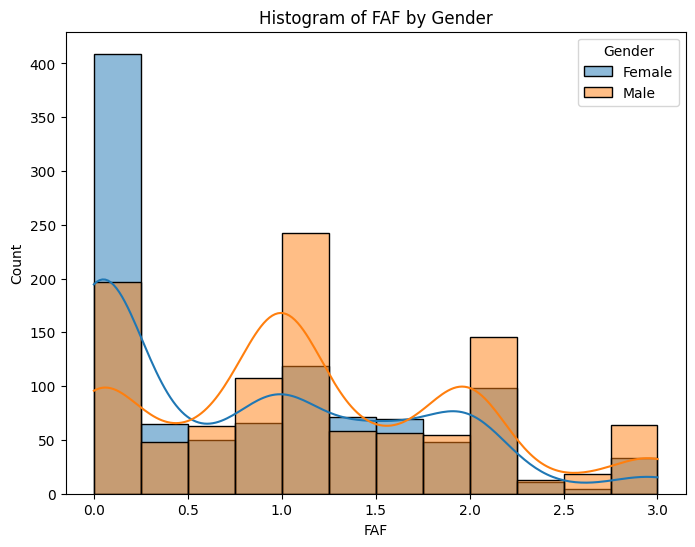

In [21]:
selected_numerical_features = ['Age', 'Weight', 'CH2O', 'FAF']
categorical_feature = 'Gender'
for feature in selected_numerical_features:
    plt.figure(figsize=(8, 6))
    for category in df[categorical_feature].unique():
        sns.histplot(df[df[categorical_feature] == category][feature], kde=True, label=category)
    plt.title(f'Histogram of {feature} by {categorical_feature}')
    plt.xlabel(feature)
    plt.legend(title=categorical_feature)
    plt.show()

**DATA PREPROCESSING**

In [22]:
def encode(df,column,d):
    c = df[column].astype('category')
    d_tem  = dict(enumerate(c.cat.categories))
    d[column] = d_tem
    df[column] = df[column].astype('category').cat.codes
    return df

In [23]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [24]:
cate = ['Gender','CALC','FAVC','SCC','SMOKE','family_history_with_overweight','CAEC', 'MTRANS','NObeyesdad']

In [25]:
d = {}
for c in cate:
    df = encode(df,c,d)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [26]:
print(d)

{'Gender': {0: 'Female', 1: 'Male'}, 'CALC': {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}, 'FAVC': {0: 'no', 1: 'yes'}, 'SCC': {0: 'no', 1: 'yes'}, 'SMOKE': {0: 'no', 1: 'yes'}, 'family_history_with_overweight': {0: 'no', 1: 'yes'}, 'CAEC': {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}, 'MTRANS': {0: 'Automobile', 1: 'Bike', 2: 'Motorbike', 3: 'Public_Transportation', 4: 'Walking'}, 'NObeyesdad': {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}}


In [27]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


**DATA SCALING**

In [28]:
features=['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS']

In [29]:
prediction = ['NObeyesdad']

In [30]:
X = df[features]
Y = df[prediction]

In [31]:
X.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS
0,21,0,1.62,64.0,3,0,2.0,3.0,0,0,2.0,1,0.0,1.0,2,3
1,21,0,1.52,56.0,2,0,3.0,3.0,1,1,3.0,1,3.0,0.0,2,3
2,23,1,1.80,77.0,1,0,2.0,3.0,0,0,2.0,1,2.0,1.0,2,3
3,27,1,1.80,87.0,1,0,3.0,3.0,0,0,2.0,0,2.0,0.0,2,4
4,22,1,1.78,89.8,2,0,2.0,1.0,0,0,2.0,0,0.0,0.0,2,3


In [32]:
Y.head()

,NObeyesdad
0,1
1,1
2,1
3,5
4,6


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [34]:
model = LogisticRegression()
model.fit(X_train, y_train.to_numpy().reshape(-1,))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test.to_numpy().reshape(-1,), y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6524822695035462


In [37]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train.to_numpy().reshape(-1,))

RandomForestClassifier()

In [38]:
y_predr = rf_model.predict(X_test)

In [39]:
accuracy_rf = accuracy_score(y_test.to_numpy().reshape(-1,), y_predr)
print("Accuracy:", accuracy_rf)

Accuracy: 0.9456264775413712


In [40]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train.to_numpy().reshape(-1,))

DecisionTreeClassifier()

In [41]:
y_predd = dt_model.predict(X_test)

In [42]:
accuracy_dt = accuracy_score(y_test.to_numpy().reshape(-1,), y_predd)
print("Accuracy:", accuracy_dt)

Accuracy: 0.9267139479905437


In [43]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train.to_numpy().reshape(-1,))

KNeighborsClassifier()

In [44]:
y_predk = knn_model.predict(X_test)

In [45]:
accuracy_knn = accuracy_score(y_test.to_numpy().reshape(-1,), y_predk)
print("Accuracy:", accuracy_knn)

Accuracy: 0.8817966903073287


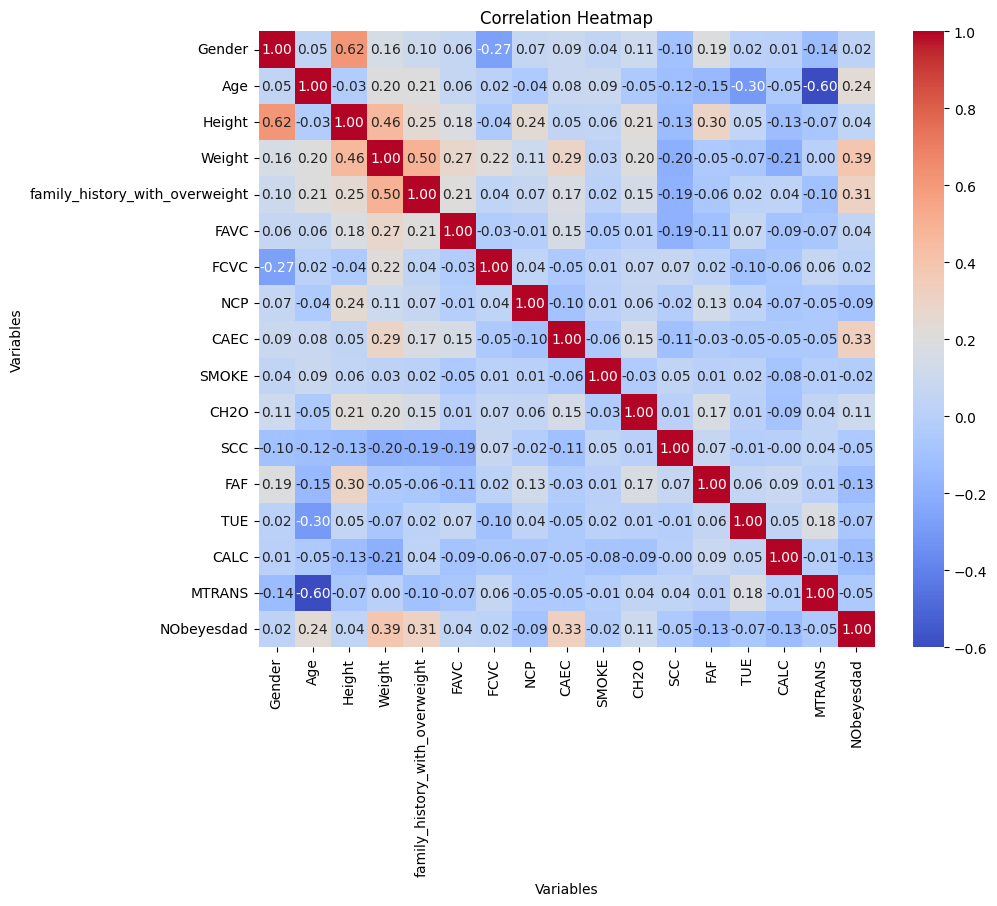

In [46]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.yticks(rotation=0)
plt.show()

In [47]:
# Calculate Misclassification Error (MCE) for each model
mce_dt = 1 - accuracy_dt
mce_rf = 1 - accuracy_rf
mce_knn = 1 - accuracy_knn

print("Misclassification Error for Decision Tree:", mce_dt)
print("Misclassification Error for Random Forest:", mce_rf)
print("Misclassification Error for KNN:", mce_knn)

Misclassification Error for Decision Tree: 0.07328605200945626
Misclassification Error for Random Forest: 0.05437352245862881
Misclassification Error for KNN: 0.11820330969267134


In [49]:
mae_knn = mean_absolute_error(y_test, y_predk)
mae_rf = mean_absolute_error(y_test, y_predr)
mae_dt = mean_absolute_error(y_test, y_predd)
print("Mean Absolute Error (MAE) for KNN:", mae_knn)
print("Mean Absolute Error (MAE) for Random Forest:", mae_rf)
print("Mean Absolute Error (MAE) for Decision Tree:", mae_dt)


Mean Absolute Error (MAE) for KNN: 0.3309692671394799
Mean Absolute Error (MAE) for Random Forest: 0.15130023640661938
Mean Absolute Error (MAE) for Decision Tree: 0.18203309692671396


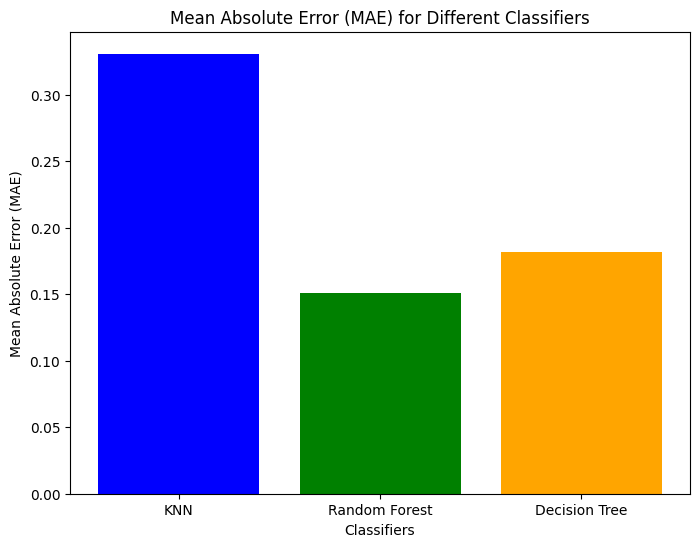

In [50]:
classifiers = ['KNN', 'Random Forest', 'Decision Tree']
mae_values = [mae_knn, mae_rf, mae_dt]

plt.figure(figsize=(8, 6))
plt.bar(classifiers, mae_values, color=['blue', 'green', 'orange'])
plt.xlabel('Classifiers')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Mean Absolute Error (MAE) for Different Classifiers')
plt.show()

In [51]:
knn_r2 = r2_score(y_test, y_predk)
rf_r2 = r2_score(y_test, y_predr)
dt_r2 = r2_score(y_test, y_predd)
print("r square  Error  for KNN:", knn_r2)
print("r square Error  for Random Forest:", rf_r2)
print("r square Error  for Decision Tree:", dt_r2)


r square  Error  for KNN: 0.6748202222706472
r square Error  for Random Forest: 0.8553334059707998
r square Error  for Decision Tree: 0.8354897581172369


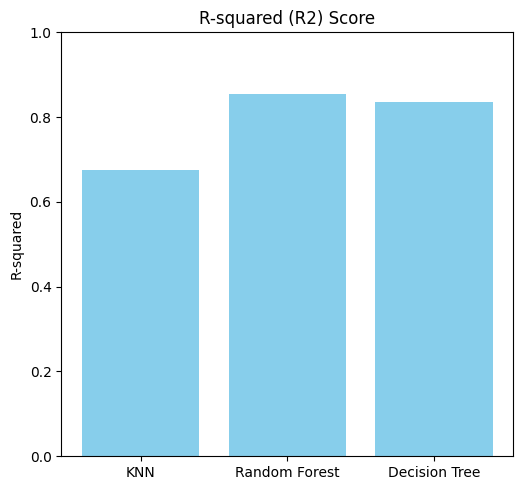

In [52]:
models = ['KNN', 'Random Forest', 'Decision Tree']
r2_values = [knn_r2, rf_r2, dt_r2]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(models, r2_values, color='skyblue')
plt.title('R-squared (R2) Score')
plt.ylabel('R-squared')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [53]:
knn_mse = mean_squared_error(y_test, y_predk )
rf_mse = mean_squared_error(y_test, y_predr)
dt_mse = mean_squared_error(y_test,y_predd)
print("Mean squared Error (MSE) for KNN:", knn_mse)
print("Mean squared Error (MSE) for Random Forest:", rf_mse)
print("Mean squared Error (MSE) for Decision Tree:", dt_mse)


Mean squared Error (MSE) for KNN: 1.2009456264775413
Mean squared Error (MSE) for Random Forest: 0.5342789598108747
Mean squared Error (MSE) for Decision Tree: 0.607565011820331


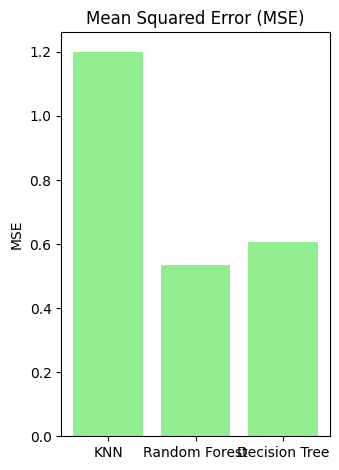

In [54]:
models = ['KNN', 'Random Forest', 'Decision Tree']
mse_values = [knn_mse, rf_mse, dt_mse]
plt.subplot(1, 2, 2)
plt.bar(models, mse_values, color='lightgreen')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

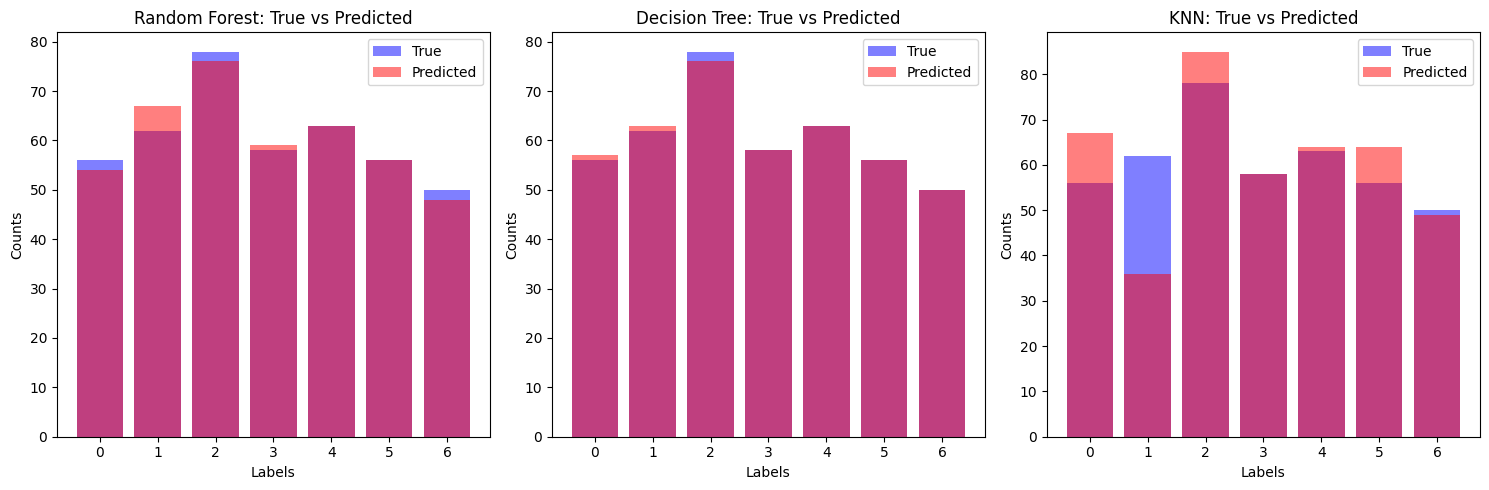

In [55]:
y_test_flat = y_test.values.flatten()
unique_labels = np.unique(np.concatenate((y_test_flat, y_predr, y_predd, y_predk)))

true_counts_rf = np.bincount(y_test_flat, minlength=len(unique_labels))
pred_counts_rf = np.bincount(y_predr, minlength=len(unique_labels))

true_counts_dt = np.bincount(y_test_flat, minlength=len(unique_labels))
pred_counts_dt = np.bincount(y_predd, minlength=len(unique_labels))

true_counts_knn = np.bincount(y_test_flat, minlength=len(unique_labels))
pred_counts_knn = np.bincount(y_predk, minlength=len(unique_labels))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(unique_labels, true_counts_rf, color='blue', alpha=0.5, label='True')
plt.bar(unique_labels, pred_counts_rf, color='red', alpha=0.5, label='Predicted')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Random Forest: True vs Predicted')
plt.legend()

plt.subplot(1, 3, 2)
plt.bar(unique_labels, true_counts_dt, color='blue', alpha=0.5, label='True')
plt.bar(unique_labels, pred_counts_dt, color='red', alpha=0.5, label='Predicted')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Decision Tree: True vs Predicted')
plt.legend()

plt.subplot(1, 3, 3)
plt.bar(unique_labels, true_counts_knn, color='blue', alpha=0.5, label='True')
plt.bar(unique_labels, pred_counts_knn, color='red', alpha=0.5, label='Predicted')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('KNN: True vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()


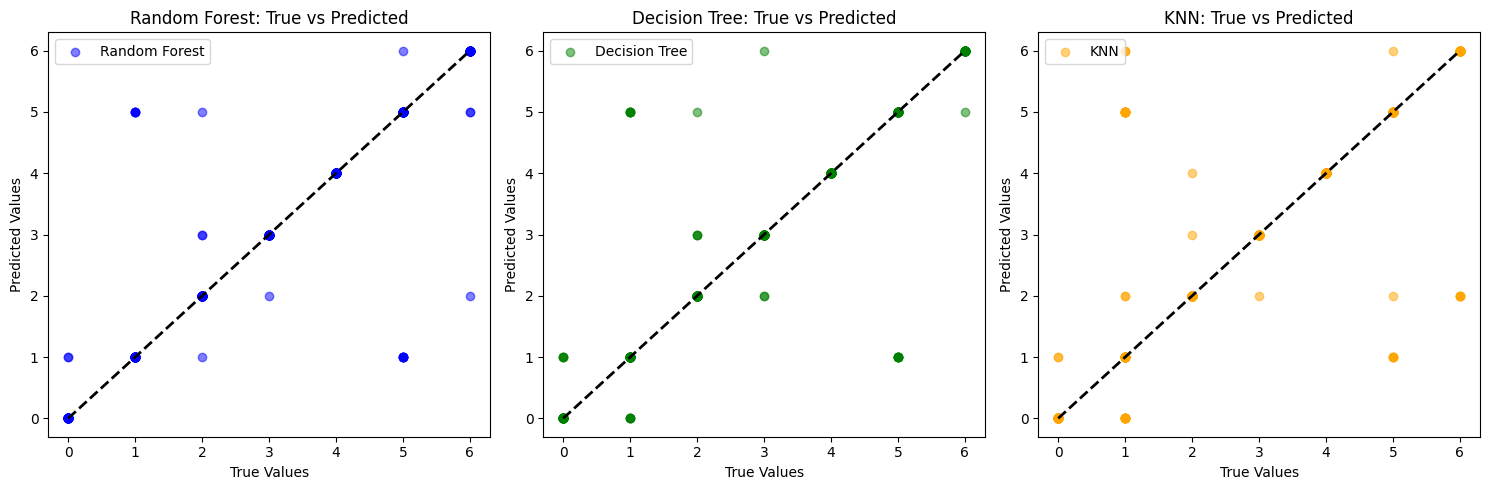

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Random Forest
plt.subplot(1, 3, 1)
plt.scatter(y_test_flat, y_predr, color='blue', alpha=0.5, label='Random Forest')
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'k--', lw=2)  # Plotting the diagonal line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: True vs Predicted')
plt.legend()

# Decision Tree
plt.subplot(1, 3, 2)
plt.scatter(y_test_flat, y_predd, color='green', alpha=0.5, label='Decision Tree')
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'k--', lw=2)  # Plotting the diagonal line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree: True vs Predicted')
plt.legend()

# KNN
plt.subplot(1, 3, 3)
plt.scatter(y_test_flat, y_predk, color='orange', alpha=0.5, label='KNN')
plt.plot([y_test_flat.min(), y_test_flat.max()], [y_test_flat.min(), y_test_flat.max()], 'k--', lw=2)  # Plotting the diagonal line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('KNN: True vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()